### GPU 기반의 CNN

In [29]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
import numpy as np
from copy import deepcopy

In [30]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(device)
torch.manual_seed(1)
if device == 'mps':
    torch.cuda.manual_seed(1)
    torch.cuda.manual_seed_all(1)

mps


In [31]:
train_raw_data = datasets.MNIST(root='./dataset', train=True, transform=transforms.ToTensor())
test_dataest = datasets.MNIST(root='./dataset', train=False, transform=transforms.ToTensor())

train_idx, val_idx, _, _ = train_test_split(range(len(train_raw_data)), train_raw_data.targets,
                                            test_size=0.2, stratify=train_raw_data.targets)

print(len(train_idx), len(val_idx))

48000 12000


In [32]:
train_dataset = Subset(train_raw_data, train_idx)
validation_dataset = Subset(train_raw_data, val_idx)

print(len(train_dataset), len(validation_dataset))

minibatch_size = 128

train_batches = DataLoader(train_dataset, minibatch_size, shuffle=True)
validation_batches = DataLoader(validation_dataset, minibatch_size, shuffle=True)
test_batches = DataLoader(test_dataest, minibatch_size, shuffle=False)

print(len(train_batches), len(validation_batches), len(test_batches))

48000 12000
375 94 79


### CNN 모델 정의 및 생성

In [33]:
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.1),
            nn.BatchNorm2d(32),
            # (28 + 2 - 3 / 1) + 1 = 27 + 1 = 28
            # (1, 32, 28, 28)
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.1),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.25),
            # (28 + 2 - 3 / 1) + 1 = 28
            # (32, 32, 14, 14)
            
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            # (14 + 2 - 3 / 1) + 1 = 14
            # (32, 64, 14, 14)
            nn.LeakyReLU(0.1),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.1),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            # (14 + 2 - 3 / 1) + 1 = 14
            # (14 - 2 / 2) + 1 = 7
            # (64, 64, 7, 7)
            
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            # (64, 64, 7, 7)
            nn.LeakyReLU(0.1),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            # (64, 128, 7, 7)
            nn.LeakyReLU(0.1),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
            # ((7 - 2) / 2) + 1 = 3.5 내림
            # (64, 128, 3, 3)
            # nn.Flatten()
        )
        
        self.linear_layers = nn.Sequential(
            nn.Linear(3 * 3 * 128, 128),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(128),
            nn.Linear(128, 10),
            nn.LogSoftmax(dim=-1)
        )
        
    def forward(self, x):
        x = self.conv_layers(x) # conv + pooling
        x = x.view(x.size(0), -1)
        return self.linear_layers(x)
      

In [34]:
model = CNNModel().to(device) # GPU 학습
model

CNNModel(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.1)
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): LeakyReLU(negative_slope=0.1)
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): LeakyReLU(negative_slope=0.1)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): LeakyReLU(negative_slope=0.1)
    (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): MaxPool2d(ke

In [35]:
# 손실 함수 및 옵티마이저 선언

loss_func = nn.NLLLoss() # log softmax는 NLLLoss() 사용
optimizer = torch.optim.Adam(model.parameters()) # Adam 사용
print(model.parameters())

<generator object Module.parameters at 0x177faf140>


In [36]:
def train_model(model, early_stop, n_epochs, progress_interval):
    train_losses, valid_losses = [], []
    lowest_loss = np.inf
    lowest_epoch = 0
    best_model = deepcopy(model.state_dict())  # 초기화

    for epoch in range(n_epochs):
        train_loss, valid_loss = 0, 0
        
        # === Train ===
        model.train()
        for x_minibatch, y_minibatch in train_batches:
            x_minibatch, y_minibatch = x_minibatch.to(device), y_minibatch.to(device)

            y_minibatch_pred = model(x_minibatch)
            loss = loss_func(y_minibatch_pred, y_minibatch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            
        train_loss /= len(train_batches)
        train_losses.append(train_loss)
        
        # === Validation ===
        model.eval()
        with torch.no_grad():
            for x_minibatch, y_minibatch in validation_batches:
                x_minibatch, y_minibatch = x_minibatch.to(device), y_minibatch.to(device)
                y_minibatch_pred = model(x_minibatch)
                loss = loss_func(y_minibatch_pred, y_minibatch)
                valid_loss += loss.item()
            
        valid_loss /= len(validation_batches)
        valid_losses.append(valid_loss)
            
        # Best model 저장
        if valid_loss < lowest_loss:
            lowest_loss = valid_loss
            lowest_epoch = epoch
            best_model = deepcopy(model.state_dict())
            print(f"Best model updated at epoch {epoch}, val_loss={valid_loss:.4f}")
        else:
            if (early_stop > 0) and (epoch - lowest_epoch) > early_stop:
                print(f"Early Stopped at epoch {epoch}")
                break
        
        if epoch % progress_interval == 0:
            print(f"[{epoch}] Train={train_loss:.4f}, Valid={valid_loss:.4f}, Best={lowest_loss:.4f}")

    model.load_state_dict(best_model)
    return model, lowest_loss, train_losses, valid_losses

In [37]:
nb_epochs = 30
progress_interval = 3
early_stop = 30
model, lowest_loss, train_losses, valid_losses =train_model(model, early_stop, nb_epochs, progress_interval)


Best model updated at epoch 0, val_loss=0.0310
[0] Train=0.1184, Valid=0.0310, Best=0.0310
Best model updated at epoch 1, val_loss=0.0301
Best model updated at epoch 2, val_loss=0.0239
Best model updated at epoch 3, val_loss=0.0207
[3] Train=0.0248, Valid=0.0207, Best=0.0207
Best model updated at epoch 5, val_loss=0.0190
[6] Train=0.0142, Valid=0.0212, Best=0.0190
Best model updated at epoch 8, val_loss=0.0155
[9] Train=0.0118, Valid=0.0175, Best=0.0155
[12] Train=0.0091, Valid=0.0187, Best=0.0155
[15] Train=0.0071, Valid=0.0235, Best=0.0155
[18] Train=0.0070, Valid=0.0189, Best=0.0155
[21] Train=0.0061, Valid=0.0213, Best=0.0155
[24] Train=0.0043, Valid=0.0204, Best=0.0155
[27] Train=0.0041, Valid=0.0200, Best=0.0155


In [38]:
test_loss = 0
correct = 0
wrong_samples, wrong_preds, actual_preds = list(), list(), list()

model.eval()
with torch.no_grad():
    for x_minibatch, y_minibatch in test_batches:
        x_minibatch = x_minibatch.to(device)
        y_minibatch = y_minibatch.to(device)
        y_test_pred = model(x_minibatch)
        test_loss += loss_func(y_test_pred, y_minibatch)
        
        pred = torch.argmax(y_test_pred, dim=1)
        correct += pred.eq(y_minibatch).sum().item()
        
        wrong_idx = pred.ne(y_minibatch).nonzero()[:, 0].cpu().numpy().tolist()
        for index in wrong_idx:
            wrong_samples.append(x_minibatch[index].cpu())
            wrong_preds.append(pred[index].cpu())
            actual_preds.append(y_minibatch[index].cpu())

test_loss /= len(test_batches.dataset)
print('Average Test Loss: {:.4f}'.format( test_loss ))
print('Accuracy: {}/{} ({:.2f}%)'.format( correct, len(test_batches.dataset), 100 * correct / len(test_batches.dataset) ))

Average Test Loss: 0.0001
Accuracy: 9936/10000 (99.36%)


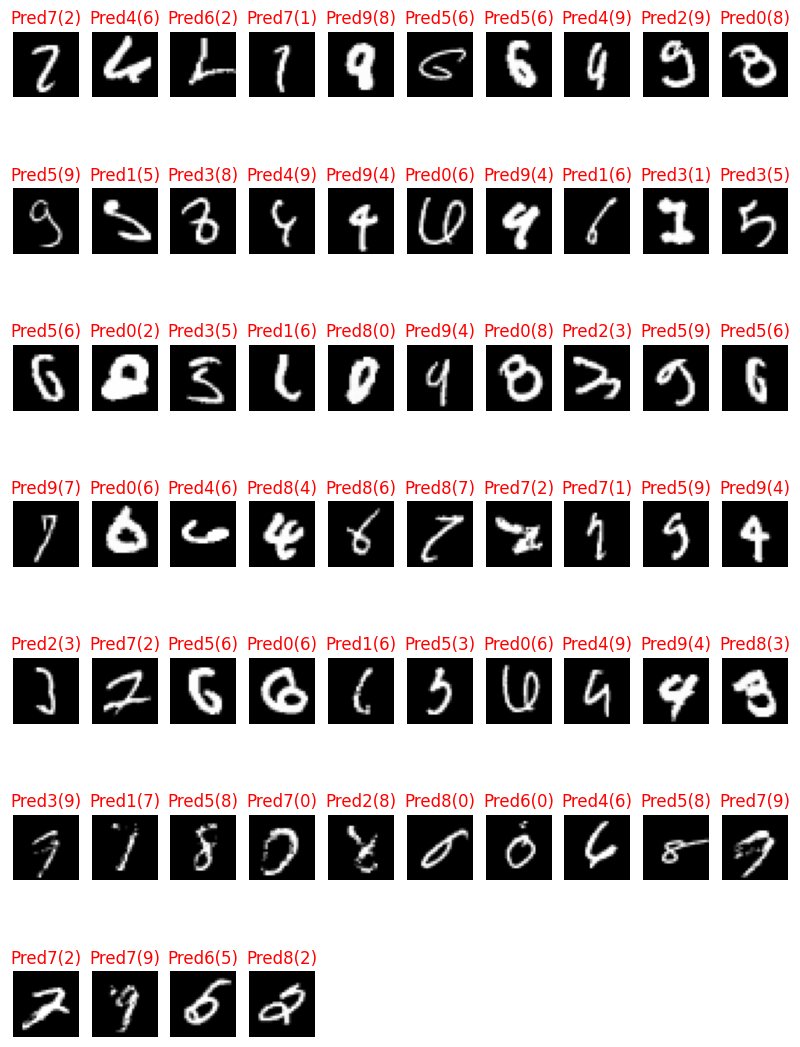

In [40]:
import matplotlib.pyplot as plt

%matplotlib inline

plt.figure(figsize=(10, 20))

for index in range(64):
    plt.subplot(10, 10, index + 1)
    plt.axis('off')
    plt.imshow(wrong_samples[index].numpy().reshape(28, 28), cmap='gray')
    plt.title("Pred" + str(wrong_preds[index].item()) + "(" + str(actual_preds[index].item()) + ")", color='red')
